## 5 - Real-Time RUL Prediction (Deployment Simulation)

**Goal:** move from offline batch evaluation (NB4) to a **streaming** setup — snapshots arrive one at a time (every ~10 min, matching the IMS sampling cadence), and the system must extract features, predict RUL + uncertainty, and issue a maintenance decision **fast enough** to keep up, with no human in the loop.

**Primary model:** Gaussian Process (best on all 6 metrics in NB4). Bayesian Ridge and MC Dropout LSTM run alongside for comparison, but the maintenance decision below is driven by GP's uncertainty.

**Demonstration data:** test3 (the held-out run from NB2/NB3/NB4) is replayed file-by-file in chronological order to *simulate* live arrival. This is a deployment-mechanics demo, not a new evaluation — test3's ground truth is already known from NB2; what's new here is proving the pipeline can go **raw file → feature → prediction → decision** within the real sampling interval, not just on a pre-extracted feature matrix. For a genuinely new (unseen) asset, the same scaler-fitting-on-first-N-healthy-snapshots step from NB2 would run once the asset starts reporting.

#### 1. Load metadata, scalers, and trained models

In [1]:
# import library
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

# reproducibility + device setup
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PREP_DIR     = './preprocessing_output'
BASELINE_DIR = './baseline_output'
BAYES_DIR    = './bayesian_output'
OUT_DIR      = './realtime_output'
os.makedirs(OUT_DIR, exist_ok=True)

with open(os.path.join(PREP_DIR, 'metadata.pkl'), 'rb') as f:
    META = pickle.load(f)

FEATURE_COLS = META['feature_cols']          # feature names, same order the models were trained on
WINDOW_SIZE  = META['window_size']           # snapshots per LSTM sequence window
MAX_RUL_TEST3 = float(META['max_rul_per_test']['test3'])   # minutes, for de-normalisation
TEST_DIRS    = META['test_dirs']          # {'test1':..., 'test2':..., 'test3':...} -- added in NB2 update
TEST_META    = META['test_meta']          # per-test n_channels / ch_map -- added in NB2 update
FAILURE_IDX  = META['failure_bearing_per_test']
HEALTHY_N    = META['healthy_n_for_scaler']   # how many initial snapshots count as 'healthy baseline'

# the bandpass band is chosen per test run (via the kurtogram, in NB2) rather than
# fixed, and must match what NB3/NB4's training features were computed with
BAND_LOWCUT, BAND_HIGHCUT = META['bandpass_band_per_test']['test3']

print(f'n_features = {len(FEATURE_COLS)} | window_size = {WINDOW_SIZE} | MAX_RUL(test3) = {MAX_RUL_TEST3:.0f} min')
print(f'test3 raw dir: {TEST_DIRS["test3"]}')
print(f'Bandpass band (test3, from metadata): {BAND_LOWCUT:.0f}-{BAND_HIGHCUT:.0f} Hz')

n_features = 15 | window_size = 30 | MAX_RUL(test3) = 1520 min
test3 raw dir: C:\Users\Windown\OneDrive\1_Dissertation\1_Project_Dissertation\3rd_test
Bandpass band (test3, from metadata): 241-541 Hz


In [2]:
# Per-test scaler (fit on test3's own healthy baseline in NB2) -- this is the
# scaler a live deployment would use for THIS asset.
with open(os.path.join(PREP_DIR, 'scalers.pkl'), 'rb') as f:
    SCALERS = pickle.load(f)
flat_scaler_test3 = SCALERS['scalers']['test3']

# Trained Bayesian Ridge + Gaussian Process (persisted at the end of NB4)
with open(os.path.join(BAYES_DIR, 'models', 'bayesian_ridge.pkl'), 'rb') as f:
    bridge_model = pickle.load(f)

with open(os.path.join(BAYES_DIR, 'models', 'gaussian_process.pkl'), 'rb') as f:
    gp_bundle = pickle.load(f)
    gp_model, gp_scaler = gp_bundle['model'], gp_bundle['scaler']

with open(os.path.join(BAYES_DIR, 'models', 'seq_scaler.pkl'), 'rb') as f:
    seq_scaler = pickle.load(f)

print('Loaded: Bayesian Ridge, Gaussian Process (+ its scaler), LSTM seq_scaler')

Loaded: Bayesian Ridge, Gaussian Process (+ its scaler), LSTM seq_scaler


In [3]:
# LSTM backbone -- same architecture as NB3/NB4, load the saved weights
class LSTMRegressor(nn.Module):
    def __init__(self, n_feat, hidden=64, layers=2, p=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True, dropout=p if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Dropout(p), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

lstm_model = LSTMRegressor(len(FEATURE_COLS)).to(device)
lstm_model.load_state_dict(torch.load(os.path.join(BASELINE_DIR, 'lstm_baseline.pt'),
                                      map_location=device))
print('Loaded LSTM backbone from', os.path.join(BASELINE_DIR, 'lstm_baseline.pt'))

Loaded LSTM backbone from ./baseline_output\lstm_baseline.pt


In [4]:
# Offline dataframe (NB2's df_test.parquet) -- needed for two things:
#  1) fitting the Health Index transform once (see 'hi' note below)
#  2) ground-truth RUL to compare against during the streamed simulation
df_test3_truth = pd.read_parquet(os.path.join(PREP_DIR, 'df_test.parquet'))
print(f'Loaded df_test.parquet: {len(df_test3_truth)} rows (test3, already smoothed by NB2)')

Loaded df_test.parquet: 6324 rows (test3, already smoothed by NB2)


#### 2. Build the real-time predictor

In [5]:
from realtime_utils import RealTimeRULPredictor

predictor = RealTimeRULPredictor(
    feature_cols=FEATURE_COLS, window_size=WINDOW_SIZE, max_rul=MAX_RUL_TEST3,
    flat_scaler=flat_scaler_test3,
    bridge_model=bridge_model,
    gp_model=gp_model, gp_scaler=gp_scaler,
    lstm_model=lstm_model, seq_scaler=seq_scaler, device=device,
    df_for_hi_fit=df_test3_truth, healthy_n=HEALTHY_N,
    lowcut=BAND_LOWCUT, highcut=BAND_HIGHCUT,   # must match NB2's per-test kurtogram band
    # Health Index ('hi') needs more than one snapshot to compute, so its
    # PCA/scaler is fit once here (offline, on the healthy baseline) and
    # reused for every new incoming snapshot
    n_mc_samples=50,
    critical_min=60.0,    # < 1 hour left (by the conservative/lower bound)  -> CRITICAL
    warning_min=180.0,    # < 3 hours left                                  -> WARNING
)
print('Real-time predictor ready. Maintenance thresholds: '
      f'CRITICAL < {predictor.critical_min:.0f} min | WARNING < {predictor.warning_min:.0f} min '
      '(based on GP\'s 90% lower bound, not just the mean -- a wide interval with a low mean '
      'should still trigger action).')

Real-time predictor ready. Maintenance thresholds: CRITICAL < 60 min | WARNING < 180 min (based on GP's 90% lower bound, not just the mean -- a wide interval with a low mean should still trigger action).


#### 3. Simulate the live stream

Replays test3's raw snapshot files in chronological order, one `ingest()` call per file — exactly what a deployed system would do as each new 10-minute snapshot arrives. The first `WINDOW_SIZE-1` snapshots have `lstm_mu = None` (not enough history yet for a sequence window) — Bayesian Ridge and GP don't have this limitation since they predict from a single snapshot.

In [6]:
import glob

test3_dir  = TEST_DIRS['test3']
ch_map     = TEST_META['test3']['ch_map']
n_channels = TEST_META['test3']['n_channels']
failure_idx = FAILURE_IDX['test3']

# IMS raw filenames are dot- or underscore-separated timestamps; try both patterns
files = sorted(glob.glob(os.path.join(test3_dir, '*.*.*.*.*.*')))
if not files:
    files = sorted(glob.glob(os.path.join(test3_dir, '*_*_*_*_*_*')))
print(f'Streaming {len(files)} snapshots from test3, one at a time...')

# Ground truth for reference/plotting only (df_test3_truth already loaded above,
# also used to fit the Health Index transform)
truth_by_filename = df_test3_truth.set_index('filename')['rul_normalized'].to_dict()

t_stream_start = time.time()
for i, fp in enumerate(files):
    y_true = truth_by_filename.get(os.path.basename(fp))
    rec = predictor.ingest(fp, ch_map, n_channels, failure_idx, y_true_norm=y_true)   # one live snapshot in
    if rec and (i + 1) % 200 == 0:
        print(f'  {i+1}/{len(files)} snapshots processed | latest status: {rec["status"]}')
t_stream_total = time.time() - t_stream_start

log = predictor.history_df()   # full per-snapshot prediction + status history
log['y_true_min'] = log['y_true_norm'] * MAX_RUL_TEST3   # convert ground truth to minutes, same units as gp_rul_min
print(f'\nDone. {len(log)} snapshots processed in {t_stream_total:.1f}s '
      f'({t_stream_total/max(len(log),1)*1000:.1f} ms/snapshot average, wall-clock).')

Streaming 6324 snapshots from test3, one at a time...
  200/6324 snapshots processed | latest status: NORMAL — no action
  400/6324 snapshots processed | latest status: NORMAL — no action
  600/6324 snapshots processed | latest status: NORMAL — no action
  800/6324 snapshots processed | latest status: NORMAL — no action
  1000/6324 snapshots processed | latest status: NORMAL — no action
  1200/6324 snapshots processed | latest status: NORMAL — no action
  1400/6324 snapshots processed | latest status: NORMAL — no action
  1600/6324 snapshots processed | latest status: NORMAL — no action
  1800/6324 snapshots processed | latest status: NORMAL — no action
  2000/6324 snapshots processed | latest status: NORMAL — no action
  2200/6324 snapshots processed | latest status: NORMAL — no action
  2400/6324 snapshots processed | latest status: NORMAL — no action
  2600/6324 snapshots processed | latest status: NORMAL — no action
  2800/6324 snapshots processed | latest status: NORMAL — no actio

#### 4. Real-time feasibility check

In [7]:
SNAPSHOT_INTERVAL_MS = 10 * 60 * 1000   # sensor delivers a new snapshot every 10 minutes

print('Per-snapshot inference latency (feature extraction + all 3 model predictions):')
print(f'  mean   : {log["latency_ms"].mean():.1f} ms')
print(f'  median : {log["latency_ms"].median():.1f} ms')
print(f'  max    : {log["latency_ms"].max():.1f} ms')
print(f'  Required budget (sensor cadence): {SNAPSHOT_INTERVAL_MS:,.0f} ms')

headroom = SNAPSHOT_INTERVAL_MS / log['latency_ms'].max()
print(f'\n=> Worst-case latency uses {100/headroom:.4f}% of the available 10-minute window '
      f'({headroom:,.0f}x headroom) — comfortably real-time capable on this hardware.')

Per-snapshot inference latency (feature extraction + all 3 model predictions):
  mean   : 90.8 ms
  median : 80.8 ms
  max    : 585.6 ms
  Required budget (sensor cadence): 600,000 ms

=> Worst-case latency uses 0.0976% of the available 10-minute window (1,025x headroom) — comfortably real-time capable on this hardware.


#### 5. Maintenance alerts raised

In [8]:
# any snapshot the predictor flagged as WARNING or CRITICAL
alerts = log[log['status'] != 'NORMAL — no action']
print(f'{len(alerts)} / {len(log)} snapshots triggered a non-normal status.')

if len(alerts):
    # first time each alert level was reached, for a quick sanity check
    first_warning = alerts[alerts['status'].str.startswith('WARNING')].head(1)
    first_critical = alerts[alerts['status'].str.startswith('CRITICAL')].head(1)
    if len(first_warning):
        r = first_warning.iloc[0]
        err = r['gp_rul_min'] - r['y_true_min']
        print(f"\nFirst WARNING  at {r['timestamp']} | GP RUL={r['gp_rul_min']:.0f} min "
              f"(90% lower bound={r['gp_lower_rul_min']:.0f} min) | "
              f"true RUL={r['y_true_min']:.0f} min (norm={r['y_true_norm']:.3f}) | error={err:+.0f} min")
    if len(first_critical):
        r = first_critical.iloc[0]
        err = r['gp_rul_min'] - r['y_true_min']
        print(f"First CRITICAL at {r['timestamp']} | GP RUL={r['gp_rul_min']:.0f} min "
              f"(90% lower bound={r['gp_lower_rul_min']:.0f} min) | "
              f"true RUL={r['y_true_min']:.0f} min (norm={r['y_true_norm']:.3f}) | error={err:+.0f} min")
else:
    print('No alerts raised -- thresholds may be too conservative for this run, or the run '
          'stays healthy throughout the streamed portion. Consider lowering warning_min/critical_min.')

116 / 6324 snapshots triggered a non-normal status.

First WARNING  at 2004-04-17 06:02:55 | GP RUL=688 min (90% lower bound=155 min) | true RUL=1240 min (norm=0.816) | error=-552 min
First CRITICAL at 2004-04-17 12:52:55 | GP RUL=916 min (90% lower bound=53 min) | true RUL=830 min (norm=0.546) | error=+86 min


#### 6. Visualize — streamed RUL predictions + maintenance zones

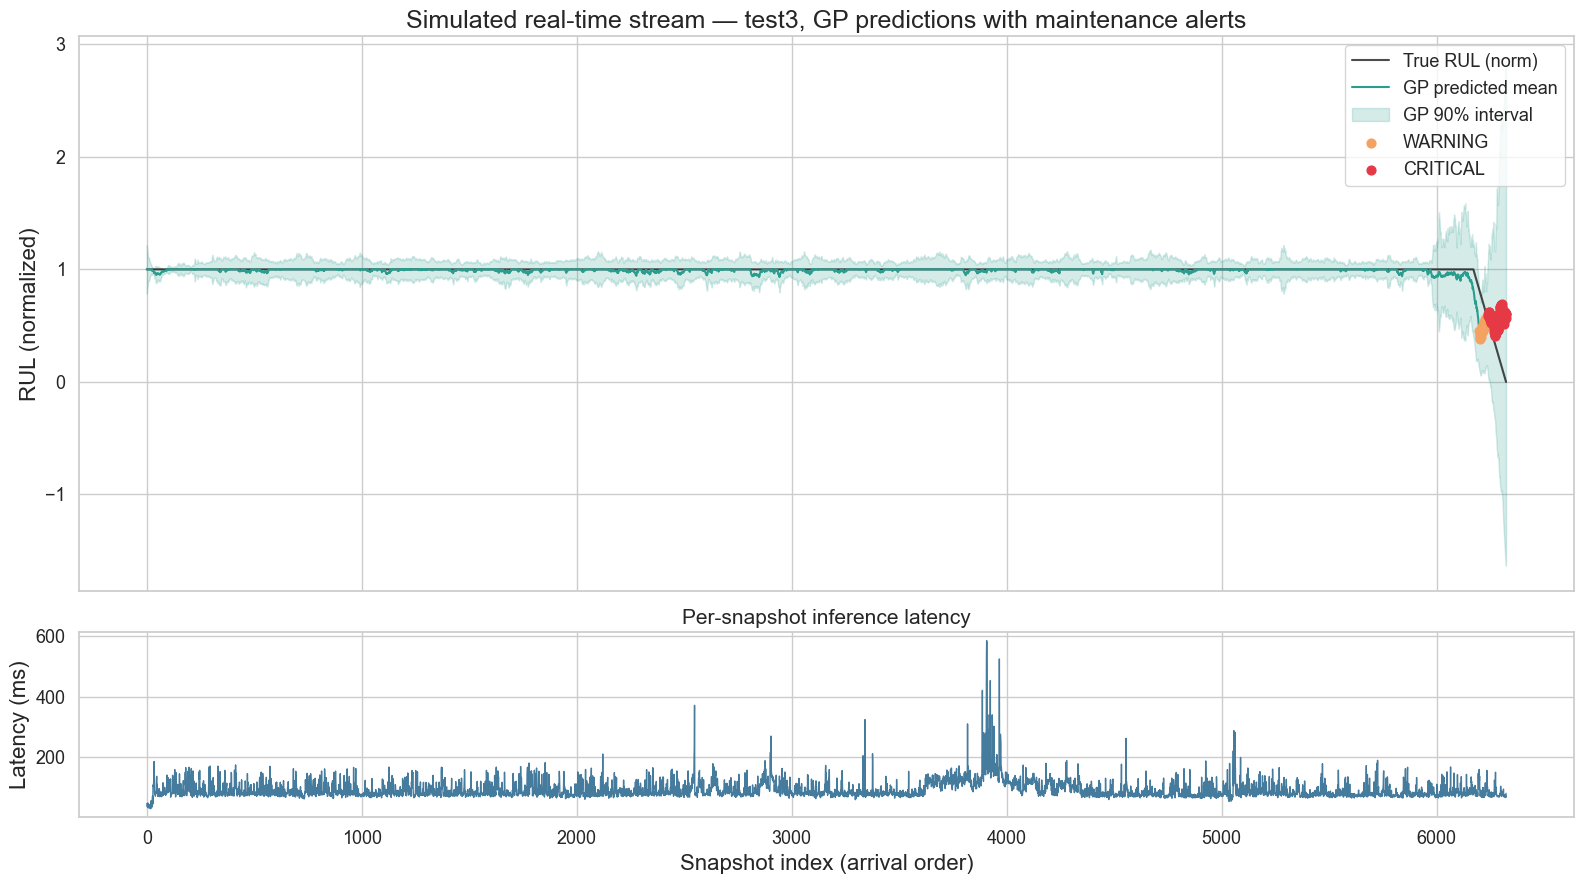

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

idx = np.arange(len(log))
ax = axes[0]
# true RUL vs GP's predicted mean, with its 90% interval as a shaded band
ax.plot(idx, log['y_true_norm'], color='black', lw=1.5, alpha=0.7, label='True RUL (norm)')
ax.plot(idx, log['gp_mu'], color='#2a9d8f', lw=1.5, label='GP predicted mean')
ax.fill_between(idx, log['gp_mu'] - 1.645*log['gp_sigma'], log['gp_mu'] + 1.645*log['gp_sigma'],
                color='#2a9d8f', alpha=0.2, label='GP 90% interval')

# mark WARNING/CRITICAL snapshots on top of the mean line
status_colors = {'NORMAL — no action': None,
                  'WARNING — monitor closely, plan maintenance window': '#f4a261',
                  'CRITICAL — schedule maintenance now': '#e63946'}
for status, c in status_colors.items():
    if c is None:
        continue
    mask = log['status'] == status
    if mask.any():
        ax.scatter(idx[mask], log['gp_mu'][mask], color=c, s=40, zorder=5, label=status.split(' — ')[0])

# larger fonts throughout — the default sizes are hard to read once the figure is scaled down
ax.set_ylabel('RUL (normalized)', fontsize=16)
ax.set_title('Simulated real-time stream — test3, GP predictions with maintenance alerts', fontsize=18)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13, loc='upper right')

# second panel: per-snapshot latency, to visualize the real-time feasibility check
axes[1].plot(idx, log['latency_ms'], color='#457b9d', lw=1.0)
axes[1].set_ylabel('Latency (ms)', fontsize=16)
axes[1].set_xlabel('Snapshot index (arrival order)', fontsize=16)
axes[1].set_title('Per-snapshot inference latency', fontsize=15)
axes[1].tick_params(axis='both', labelsize=13)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'realtime_stream.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 7. Save the streamed log

In [12]:
# Save the full streamed log + print a final summary
log_path = os.path.join(OUT_DIR, 'realtime_log.csv')
log.to_csv(log_path, index=False)
mae_min = (log['gp_rul_min'] - log['y_true_min']).abs().mean()
print('Saved to', os.path.abspath(log_path))
print(f'  {len(log)} rows | columns: {list(log.columns)}')
print(f'\nSummary: {len(alerts)} alerts / {len(log)} snapshots | '
      f'mean latency {log["latency_ms"].mean():.1f} ms (budget {SNAPSHOT_INTERVAL_MS:,.0f} ms)')
print(f'GP RUL prediction error (same units, minutes): MAE = {mae_min:.1f} min')

Saved to C:\Users\Windown\OneDrive - Aston University\1_Dissertation\1_Project_Dissertation\realtime_output\realtime_log.csv
  6324 rows | columns: ['timestamp', 'y_true_norm', 'bridge_mu', 'bridge_sigma', 'gp_mu', 'gp_sigma', 'gp_rul_min', 'gp_lower_rul_min', 'lstm_mu', 'lstm_sigma', 'status', 'latency_ms', 'y_true_min']

Summary: 116 alerts / 6324 snapshots | mean latency 90.8 ms (budget 600,000 ms)
GP RUL prediction error (same units, minutes): MAE = 20.2 min
